In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

In [2]:
mol = gto.M(
    atom=
    '''
    N   0.00000000,  0.00000000,  0.0000000
    N   1.11200000,  0.00000000,  0.0000000
    ''',
    # atom=
    # '''
    # O   0.00000000,  0.00000000,  0.00000000
    # H   0.75700000,  0.00000000,  0.58590000
    # H  -0.75700000,  0.00000000,  0.58590000
    # ''',
    basis="sto-3g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin0.FCI(mol)
solver.nroots = 3
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
e_fci = e_fci[0]
# s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
# print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,))

SCF energy : -107.498967544584
FCI energy : -107.660206420034


E0526 15:23:29.118755   15437 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0526 15:23:29.128928   15289 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


step=   0  energy=-107.49893832  variance= 0.33013390  acc=0.000  ess= 521.0  ess_frac= 0.509  unique_frac= 0.106  n_eval=1971.0
         times: backward= 0.6460 | forward= 0.3980 | graph= 0.0080 | optimizer= 2.8209 | reduce= 0.0016 | sample= 0.0064 | total= 3.8811
step=  10  energy=-107.62669763  variance= 0.01689332  acc=0.056  ess= 442.8  ess_frac= 0.432  unique_frac= 0.144  n_eval=2787.0
         times: backward= 0.0623 | forward= 0.1568 | graph= 0.0102 | optimizer= 0.2595 | reduce= 0.0035 | sample= 0.0074 | total= 0.5000
step=  20  energy=-107.64910140  variance= 0.00715746  acc=0.127  ess= 344.5  ess_frac= 0.336  unique_frac= 0.223  n_eval=3361.0
         times: backward= 0.0601 | forward= 0.1101 | graph= 0.0137 | optimizer= 0.2601 | reduce= 0.0036 | sample= 0.0077 | total= 0.4556
step=  30  energy=-107.65602058  variance= 0.00688642  acc=0.155  ess= 281.7  ess_frac= 0.275  unique_frac= 0.269  n_eval=3416.0
         times: backward= 0.0610 | forward= 0.1586 | graph= 0.0147 | opti

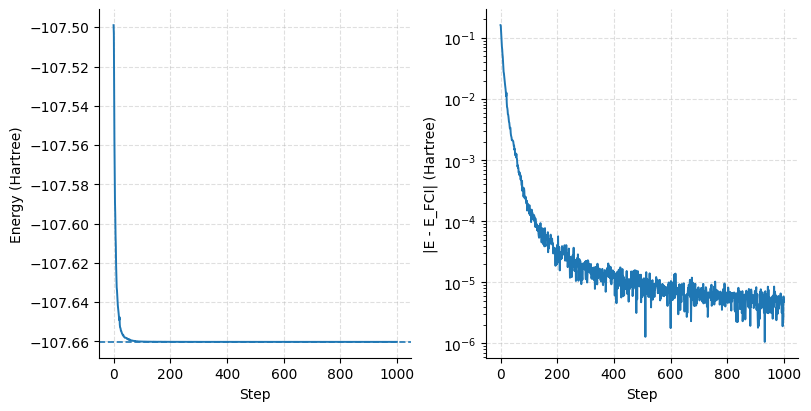

In [ ]:
sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=1024,
    alpha=1.0,
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="hf",
    key=jax.random.key(0),
)

steps = 1000
optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []

for step in range(steps):
    stats = vmc.step()
    history.append(stats['energy'])

    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:4d}  "
            f"energy={history[-1]: .8f}  "
            f"variance={stats['variance']: .8f}  "
            f"acc={stats['accept']:.3f}  "
            f"ess={stats['ess']: .1f}  "
            f"n_unique={stats['n_unique']: .3f}  "
            f"n_eval={stats['n_eval']:}"
        )

        time_items = sorted(
            (k[5:], float(stats[k])) for k in stats if k.startswith("time_")
        )
        if time_items:
            line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
            print(f"         times: " + line)

plot_convergence(history, e_fci)
plt.show()